## Косарский Иван, ПМИ-3

## Обучение с подкреплением

### Среда - OpenAI Gym

In [1]:
!pip install dm-haiku
import copy
from shutil import rmtree # deleting directories
import random
import collections # useful data structures
import numpy as np
import gym # reinforcement learning environments
from gym.wrappers import RecordVideo
import jax
import jax.numpy as jnp # jax numpy
import optax # jax optimizer library
import haiku as hk
import matplotlib.pyplot as plt # graph plotting library
from IPython.display import HTML
from base64 import b64encode
import chex

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 373.9/373.9 kB 5.7 MB/s eta 0:00:00


In [2]:
env_name = "CartPole-v0"
env = gym.make(env_name)

/usr/local/lib/python3.10/dist-packages/gym/envs/registration.py:593: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(
/usr/local/lib/python3.10/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.10/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(


### Состояния (States) и наблюдение (Obserbvations) - st and ot

In [3]:
s_0 = env.reset()
print("Initial State::", s_0)

obs_shape = env.observation_space.shape
print("Environment Obs Space Shape:", obs_shape)

Initial State:: [ 0.00618434  0.04955956 -0.03295443 -0.00418611]
Environment Obs Space Shape: (4,)


### Действия - at

In [4]:
print(f"Environment action space: {env.action_space}")

num_actions = env.action_space.n
print(f"Number of actions: {num_actions}")

Environment action space: Discrete(2)
Number of actions: 2


### Политика агента №1

In [5]:
def linear_policy(params, obs):
    dot_product_result = jnp.dot(params, obs)

    action = jax.lax.select(
        dot_product_result > 0,
        1,
        0
    )

    return action

In [6]:
def check_linear_policy(linear_policy):
  fixed_obs = jnp.array([1,1,2,4])

  params1 = jnp.array([1,1,1,1])
  params2 = jnp.array([-1,-1,-1,-1])

  hint1 = f"Неправильный ответ, ваша линейная политика неверна. Действие при \
obs={fixed_obs} и params={params1} должно быть 1"

  hint2 = f"Неправильный ответ, ваша линейная политика неверна. Действие при \
obs={fixed_obs} и params={params2} должно быть 0"

  hint = None
  if linear_policy(params1, fixed_obs) != 1:
    hint = hint1
  elif linear_policy(params2, fixed_obs) != 0:
    hint = hint2

  if hint is not None:
    print(hint)
  else:
    print("Your function is correct!")

try:
  check_linear_policy(linear_policy)
except Exception as e:
    print("An Error Occured: {}".format(e))

Your function is correct!


### Функция перехода среды - P

In [7]:
initial_obs = env.reset()

action = env.action_space.sample()
next_obs, reward, terminated, info = env.step(action)

next_obs, reward, done, info = env.step(action)

print("Observation:", initial_obs)
print("Action:", action)
print("Next observation:", next_obs)
print("Reward:", reward)
print("Game is done:", done)

Observation: [-0.00691717 -0.04624286 -0.04283708 -0.00976276]
Action: 0
Next observation: [-0.01265653 -0.4352074  -0.03765028  0.5479085 ]
Reward: 1.0
Game is done: False


/usr/local/lib/python3.10/dist-packages/gym/utils/passive_env_checker.py:241: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


### Цикл агент-среда №2

In [8]:
def run_episode(env):
    episode_return = 0
    done = False
    params = jnp.array([1, -2, 2, -1])
    obs, _ = env.reset()

    while not done:
        action = np.array(1 if jnp.dot(params, obs) > 0 else 0)
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        episode_return += reward

    return episode_return

In [9]:
try:
    env.reset(seed=42)
    if run_episode(env) == 31:
        print("Looks correct!")
    else:
        print("Looks like your implementation might be wrong.")
except Exception as e:
    print("An Error Occured: {}".format(e))

An Error Occured: too many values to unpack (expected 2)


### Цикл обучения RL общего назначения

In [20]:
#@title Training loop (run me) { display-mode: "form" }

# NamedTuple to store transitions
Transition = collections.namedtuple("Transition", ["obs", "action", "reward", "next_obs", "done"])

# Training Loop
def run_training_loop(env_name, agent_params, agent_select_action_func,
    agent_actor_state=None, agent_learn_func=None, agent_learner_state=None,
    agent_memory=None, num_episodes=1000, evaluator_period=100,
    evaluation_episodes=8, learn_steps_per_episode=1,
    train_every_timestep=False, video_subdir="",):
    """
    This function runs several episodes in an environment and periodically does
    some agent learning and evaluation.

    Args:
        env: a gym environment.
        agent_params: an object to store parameters that the agent uses.
        agent_select_func: a function that does action selection for the agent.
        agent_actor_state (optional): an object that stores the internal state
            of the agents action selection function.
        agent_learn_func (optional): a function that does some learning for the
            agent by updating the agent parameters.
        agent_learn_state (optional): an object that stores the internal state
            of the agent learn function.
        agent_memory (optional): an object for storing an retrieving historical
            experience.
        num_episodes: how many episodes to run.
        evaluator_period: how often to run evaluation.
        evaluation_episodes: how many evaluation episodes to run.
        train_every_timestep: whether to train every timestep rather than at the end
            of the episode.
        video_subdir: subdirectory to store epsiode recordings.

    Returns:
        episode_returns: list of all the episode returns.
        evaluator_episode_returns: list of all the evaluator episode returns.
    """

    # Setup Cartpole environment and recorder
    env = gym.make(env_name, render_mode="rgb_array") # training environment
    eval_env = gym.make(env_name, render_mode="rgb_array") # evaluation environment

    # Video dir
    video_dir = "./video"+"/"+video_subdir

    # Clear video dir
    try:
      rmtree(video_dir)
    except:
      pass

    # Wrap in recorder
    env = RecordVideo(env, video_dir+"/train", episode_trigger=lambda x: (x % evaluator_period) == 0)
    eval_env = RecordVideo(eval_env, video_dir+"/eval", episode_trigger=lambda x: (x % evaluation_episodes) == 0)

    # JAX random number generator
    rng = hk.PRNGSequence(jax.random.PRNGKey(0))
    env.reset(seed=0)

    episode_returns = [] # List to store history of episode returns.
    evaluator_episode_returns = [] # List to store history of evaluator returns.
    timesteps = 0
    for episode in range(num_episodes):

        # Reset environment.
        obs = env.reset()
        episode_return = 0
        done = False

        while not done:

            # Agent select action.
            action, agent_actor_state = agent_select_action_func(
                                            next(rng),
                                            agent_params,
                                            agent_actor_state,
                                            np.array(obs)
                                        )

            # Step environment.
            next_obs, reward, done, _ = env.step(int(action))

            # Pack into transition.
            transition = Transition(obs, action, reward, next_obs, done)

            # Add transition to memory.
            if agent_memory: # check if agent has memory
              agent_memory.push(transition)

            # Add reward to episode return.
            episode_return += reward

            # Set obs to next obs before next environment step. CRITICAL!!!
            obs = next_obs

            # Increment timestep counter
            timesteps += 1

            # Maybe learn every timestep
            if train_every_timestep and (timesteps % 4 == 0) and agent_memory and agent_memory.is_ready(): # Make sure memory is ready
                # First sample memory and then pass the result to the learn function
                memory = agent_memory.sample()
                agent_params, agent_learner_state = agent_learn_func(
                                                        next(rng),
                                                        agent_params,
                                                        agent_learner_state,
                                                        memory
                                                    )

        episode_returns.append(episode_return)

        # At the end of every episode we do a learn step.
        if agent_memory and agent_memory.is_ready(): # Make sure memory is ready

            for _ in range(learn_steps_per_episode):
                # First sample memory and then pass the result to the learn function
                memory = agent_memory.sample()
                agent_params, agent_learner_state = agent_learn_func(
                                                        next(rng),
                                                        agent_params,
                                                        agent_learner_state,
                                                        memory
                                                    )

        if (episode % evaluator_period) == 0: # Do evaluation

            evaluator_episode_return = 0
            for eval_episode in range(evaluation_episodes):
                obs = eval_env.reset()
                done = False
                while not done:
                    action, _ = agent_select_action_func(
                                    next(rng),
                                    agent_params,
                                    agent_actor_state,
                                    np.array(obs),
                                    evaluation=True
                                )

                    obs, reward, done, _ = eval_env.step(int(action))

                    evaluator_episode_return += reward

            evaluator_episode_return /= evaluation_episodes

            evaluator_episode_returns.append(evaluator_episode_return)

            logs = [
                    f"Episode: {episode}",
                    f"Episode Return: {episode_return}",
                    f"Average Episode Return: {np.mean(episode_returns[-20:])}",
                    f"Evaluator Episode Return: {evaluator_episode_return}"
            ]

            print(*logs, sep="\t") # Print the logs

    env.close()
    eval_env.close()

    return episode_returns, evaluator_episode_returns

### Случайный поиск политики

In [21]:
# Parameter container for Random Policy Search
RandomPolicySearchParams = collections.namedtuple("RandomPolicySearchParams", ["current", "best"])

# TEST: store two different sets of parameters
current_params = np.ones(obs_shape) * -1
best_params = np.zeros(obs_shape)
rps_params = RandomPolicySearchParams(current_params, best_params)

# How to access the best or current params.
print(f"Best params: {rps_params.best}")
print(f"Current params: {rps_params.current}")

Best params: [0. 0. 0. 0.]
Current params: [-1. -1. -1. -1.]


### Функция выбора действия №3

In [33]:
def random_policy_search_choose_action(
    key,
    params,
    actor_state,
    obs,
    evaluation=False
):
    # Вычисление действия для best_params и current_params
    best_action = jnp.dot(params.best, obs) > 0
    current_action = jnp.dot(params.current, obs) > 0

    # Выбор действия в зависимости от evaluation
    action = jax.lax.select(
        evaluation,  # Условие
        jnp.where(best_action, 1, 0),  # Действие для best_params
        jnp.where(current_action, 1, 0)  # Действие для current_params
    )

    return action, actor_state


In [34]:
def check_random_policy_search_choose_action(choose_action):
  key = None # not used
  actor_state = None # not used

  # obs
  obs = np.ones(obs_shape)

  evaluation=False
  current_params = np.ones(obs_shape) * -1
  best_params = np.ones(obs_shape)
  rps_params = RandomPolicySearchParams(current_params, best_params)
  action, actor_state = choose_action(key,rps_params,actor_state,obs,evaluation)
  if action != 0:
    return False

  evaluation=True
  current_params = np.ones(obs_shape) * -1
  best_params = np.ones(obs_shape)
  rps_params = RandomPolicySearchParams(current_params, best_params)
  action, actor_state = choose_action(key,rps_params,actor_state,obs,evaluation)
  if action != 1:
    return False

  return True

try:
  if check_random_policy_search_choose_action(random_policy_search_choose_action):
    print("Your function looks correct.")
  else:
    print("Your function looks incorrect.")
except Exception as e:
    print("An Error Occured: {}".format(e))


Your function looks correct.


### Память агента RPS

In [35]:
class AverageEpisodeReturnBuffer:

    def __init__(self, num_episodes_to_store=50):
        """
        This class implements an agent memory that stores the average episode
        return over the last 50 episodes.
        """
        self.num_episodes_to_store = num_episodes_to_store
        self.episode_return_buffer = []
        self.current_episode_return = 0

    def push(self, transition):
        self.current_episode_return += transition.reward

        if transition.done: # If the episode is done
            # Add episode return to buffer
            self.episode_return_buffer.append(self.current_episode_return)

            # Reset episode return
            self.current_episode_return = 0


    def is_ready(self):
        return len(self.episode_return_buffer) == self.num_episodes_to_store

    def sample(self):
        average_episode_return = np.mean(self.episode_return_buffer)

        # Clear episode return buffer
        self.episode_return_buffer = []

        return average_episode_return

### Функция обучения RPS №4

In [36]:
def get_new_random_weights(random_key, old_weights, minval=-2.0, maxval=2.0):
    new_params = jax.random.uniform(
        random_key,
        shape=old_weights.shape,
        dtype=old_weights.dtype,
        minval=minval,
        maxval=maxval
    )
    return new_params

In [37]:
# A NamedTuple to store the best average episode return so far
RandomPolicyLearnState = collections.namedtuple(
  "RandomPolicyLearnState",
  ["best_average_episode_return"]
)

# Test
initial_learn_state = RandomPolicyLearnState(best_average_episode_return=-float("inf"))
print("Initial best average episode return:", initial_learn_state.best_average_episode_return)

Initial best average episode return: -inf


### Случайная проверка №5

In [38]:
def random_policy_search_learn(key, params, learn_state, memory):
    best_params = params.best
    current_params = params.current

    current_average_episode_return = memory  # the memory contains the average episode return
    best_average_episode_return = learn_state.best_average_episode_return

    # Update the best parameters and the best average return using jax.lax.select
    best_params = jax.lax.select(
        current_average_episode_return > best_average_episode_return,
        current_params,
        best_params
    )

    best_average_episode_return = jax.lax.select(
        current_average_episode_return > best_average_episode_return,
        current_average_episode_return,
        best_average_episode_return
    )

    # Generate new random parameters
    new_params = get_new_random_weights(key, current_params)

    # Bundle weights in RandomPolicySearchParams NamedTuple
    params = RandomPolicySearchParams(current=new_params, best=best_params)

    return params, RandomPolicyLearnState(best_average_episode_return)

In [39]:
params = RandomPolicySearchParams(np.ones(obs_shape, "float32"), np.ones(obs_shape, "float32") * -1)
learn_state = RandomPolicyLearnState(10)
memory = 11
key = jax.random.PRNGKey(42)

try:
  new_params, new_learn_state = random_policy_search_learn(key, params, learn_state, memory)

  if not jnp.array_equal(new_params.current, jnp.array([ 0.29657745,  1.4265499 , -1.7621555 , -1.7505779 ])):
    print("Your function is incorrect.")

  elif not jnp.array_equal(new_params.best, jnp.array([1., 1., 1., 1.])):
    print("Your function is incorrect.")

  elif new_learn_state.best_average_episode_return != 11:
    print("Your function is incorrect.")

  else:
    print("Your function looks correct.")
except Exception as e:
    print("An Error Occured: {}".format(e))

Your function looks correct.


### Цикл обучения RPS

Starting training. This may take up to 5 minutes to complete.


/usr/local/lib/python3.10/dist-packages/gym/envs/registration.py:593: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(
/usr/local/lib/python3.10/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.10/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/lib/python3.10/subprocess.py:1796: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.p

Episode: 0	Episode Return: 99.0	Average Episode Return: 99.0	Evaluator Episode Return: 124.875


/usr/lib/python3.10/subprocess.py:1796: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _posixsubprocess.fork_exec(
/usr/lib/python3.10/subprocess.py:1796: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _posixsubprocess.fork_exec(


Episode: 100	Episode Return: 10.0	Average Episode Return: 24.2	Evaluator Episode Return: 154.875


...

Episode: 800	Episode Return: 10.0	Average Episode Return: 190.5	Evaluator Episode Return: 200.0


/usr/lib/python3.10/subprocess.py:1796: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _posixsubprocess.fork_exec(
/usr/lib/python3.10/subprocess.py:1796: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _posixsubprocess.fork_exec(


Episode: 900	Episode Return: 9.0	Average Episode Return: 9.5	Evaluator Episode Return: 200.0


/usr/lib/python3.10/subprocess.py:1796: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _posixsubprocess.fork_exec(
/usr/lib/python3.10/subprocess.py:1796: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _posixsubprocess.fork_exec(


Episode: 1000	Episode Return: 10.0	Average Episode Return: 190.5	Evaluator Episode Return: 200.0


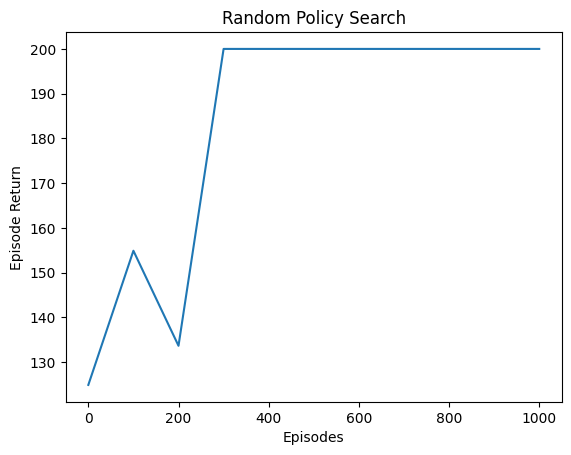

In [40]:
# JIT the learn and choose action functions
random_policy_search_learn_jit = jax.jit(random_policy_search_learn)
random_policy_search_choose_action_jit = jax.jit(random_policy_search_choose_action)

# Initialise the parameters
initial_weights = np.ones(obs_shape, "float32")
initial_params = RandomPolicySearchParams(initial_weights, initial_weights)

# Initialise the learn state
initial_learn_state = RandomPolicyLearnState(best_average_episode_return=-float("inf"))

# Initialise memory
memory = AverageEpisodeReturnBuffer(num_episodes_to_store=50)

# Run the training loop
print("Starting training. This may take up to 5 minutes to complete.")
chex.clear_trace_counter()
episode_return, evaluator_episode_returns = run_training_loop(
                                        env_name,
                                        initial_params,
                                        random_policy_search_choose_action_jit,
                                        None, # no actor state
                                        random_policy_search_learn_jit,
                                        initial_learn_state,
                                        memory,
                                        num_episodes=1001,
                                        video_subdir="rps"
                                    )

# Plot graph of evaluator episode returns
plt.plot(np.linspace(0, 1000, len(evaluator_episode_returns)), evaluator_episode_returns)
plt.title("Random Policy Search")
plt.xlabel("Episodes")
plt.ylabel("Episode Return")
plt.show()

In [42]:
#@title Visualise Policy {display-mode: "form"}
#@markdown Choose an episode number that is a multiple of 100 and less than or equal to 2000, and **run** this cell.
episode_number = 1000 #@param {type:"number"}

assert (episode_number % 100) == 0, "Episode number must be a multiple of 100 since we only record every 100th episode."
assert episode_number < 1001, "Episode number must be less than or equal to 2000"

eval_episode_number = int(episode_number / 100 * 8)
video_path = f"./video/rps/eval/rl-video-episode-{eval_episode_number}.mp4"

mp4 = open(video_path,'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML("""
<video width=400 controls>
      <source src="%s" type="video/mp4">
</video>
""" % data_url)

### Градиенты политики

### Вероятность действия №6

In [43]:
def compute_weighted_log_prob(action_prob, episode_return):
    log_prob = jnp.log(action_prob)

    weighted_log_prob = log_prob * episode_return

    return weighted_log_prob

In [44]:
#@title Проверка упр 6 {display-mode: "form"}

try:
  action_prob = 0.8
  episode_return = 100
  result = compute_weighted_log_prob(action_prob, episode_return)
  if result != -22.314354:
    print("Your implementation looks incorrect.")
  else:
    print("Looks correct.")
except Exception as e:
    print("An Error Occured: {}".format(e))

Looks correct.


### Вычисление оставшихся наград №7

In [45]:
def compute_rewards_to_go(rewards):
    """
    This function should take a list of rewards as input and
    compute the rewards-to-go for each timestep.

    EXAMPLE: compute_rewards_to_go([1,2,3,4]) = [10, 9, 7, 4]
    """
    rewards_to_go = []
    for i in range(len(rewards)):
        rewards_to_go.append(sum(rewards[i:]))

    return rewards_to_go

In [46]:
#@title Проверка упр 7 {display-mode: "form"}

try:
  result = compute_rewards_to_go([1,2,3,4])

  if result != [10, 9, 7, 4]:
    print("There is a problem with your implementation.")
  else:
    print("Looks correct.")
except Exception as e:
    print("An Error Occured: {}".format(e))

Looks correct.


### Реализация памяти

In [47]:
# @title Реализация памяти (run me) {display-mode: "form"}

# NamedTuple to store memory
EpisodeRewardsToGoMemory = collections.namedtuple("EpisodeRewardsToGoMemory", ["obs", "action", "reward_to_go"])

class EpisodeRewardsToGoBuffer:

    def __init__(self, num_transitions_to_store=512, batch_size=256):
        self.batch_size = batch_size
        self.memory_buffer = collections.deque(maxlen=num_transitions_to_store)
        self.current_episode_transition_buffer = []

    def push(self, transition):
        self.current_episode_transition_buffer.append(transition)

        if transition.done:

            episode_rewards = []
            for t in self.current_episode_transition_buffer:
                episode_rewards.append(t.reward)

            r2g = compute_rewards_to_go(episode_rewards)

            for i, t in enumerate(self.current_episode_transition_buffer):
                memory = EpisodeRewardsToGoMemory(t.obs, t.action, r2g[i])
                self.memory_buffer.append(memory)

            # Reset episode buffer
            self.current_episode_transition_buffer = []


    def is_ready(self):
        return len(self.memory_buffer) >= self.batch_size

    def sample(self):
        random_memory_sample = random.sample(self.memory_buffer, self.batch_size)

        obs_batch, action_batch, reward_to_go_batch = zip(*random_memory_sample)

        return EpisodeRewardsToGoMemory(
            np.stack(obs_batch).astype("float32"),
            np.asarray(action_batch).astype("int32"),
            np.asarray(reward_to_go_batch).astype("int32")
        )


# Instantiate Memory
REINFORCE_memory = EpisodeRewardsToGoBuffer(num_transitions_to_store=512, batch_size=256)

### Policy neural network

In [48]:
def make_policy_network(num_actions: int, layers=[20, 20]) -> hk.Transformed:
  """Factory for a simple MLP network for the policy."""

  def policy_network(obs):
    network = hk.Sequential(
        [
            hk.Flatten(),
            hk.nets.MLP(layers + [num_actions])
        ]
    )
    return network(obs)

  return hk.without_apply_rng(hk.transform(policy_network))

In [49]:
# Example
POLICY_NETWORK = make_policy_network(num_actions=num_actions, layers=[20,20])
random_key = jax.random.PRNGKey(42) # random key
dummy_obs = np.ones(obs_shape, "float32")

# Initialise parameters
REINFORCE_params = POLICY_NETWORK.init(random_key, dummy_obs)
print("Initial params:", REINFORCE_params.keys())

# Pass input through the network
output = POLICY_NETWORK.apply(REINFORCE_params, dummy_obs)
print("Policy network output:", output)

Initial params: dict_keys(['mlp/~/linear_0', 'mlp/~/linear_1', 'mlp/~/linear_2'])
Policy network output: [ 0.91155875 -0.3961737 ]


### УСИЛЕНИЕ выбор функции действия №8

In [50]:
def sample_action(random_key, logits):
    probabilities = jax.nn.softmax(logits)

    action = jax.random.categorical(random_key, jnp.log(probabilities))

    return action

In [51]:
#@title Проверка упр 8 {display-mode: "form"}

try:
  random_key = jax.random.PRNGKey(42) # random key
  action = sample_action(random_key, np.array([1,2], "float32"))
  if action != 1:
    print("Your function is incorrect.")
  else:
    print("Seems correct.")
except Exception as e:
    print("An Error Occured: {}".format(e))

Seems correct.


In [52]:
def REINFORCE_choose_action(key, params, actor_state, obs, evaluation=False):
  obs = jnp.expand_dims(obs, axis=0) # add dummy batch dim before passing through network

  # Pass obs through policy network to compute logits
  logits = POLICY_NETWORK.apply(params, obs)
  logits = logits[0] # remove batch dim

  # Randomly sample action
  sampled_action = sample_action(key, logits)

  return sampled_action, actor_state

### Policy gradient loss №9

In [53]:
def policy_gradient_loss(action, logits, reward_to_go):
    all_action_probs = jax.nn.softmax(logits)

    action_prob = all_action_probs[action]

    weighted_log_prob = jnp.log(action_prob) * reward_to_go

    loss = -weighted_log_prob

    return loss

In [54]:
def batched_policy_gradient_loss(params, obs_batch, action_batch, reward_to_go_batch):
    # Get logits by passing observation through network
    logits_batch = POLICY_NETWORK.apply(params, obs_batch)

    policy_gradient_loss_batch = jax.vmap(policy_gradient_loss)(
        action_batch,
        logits_batch,
        reward_to_go_batch) # add batch

    # Compute mean loss over batch
    mean_policy_gradient_loss = jnp.mean(policy_gradient_loss_batch)

    return mean_policy_gradient_loss

# TEST
obs_batch = np.ones((3, *obs_shape), "float32")
actions_batch = np.array([1,0,0])
rew2go_batch = np.array([2.3, 4.3, 2.1])

loss = batched_policy_gradient_loss(REINFORCE_params, obs_batch, actions_batch, rew2go_batch)

print("Policy gradient loss on batch:", loss)

Policy gradient loss on batch: 1.6967314


### Оптимизатор сети

In [55]:
REINFORCE_OPTIMIZER = optax.adam(1e-3)

# Initialise the optimiser
REINFORCE_optim_state = REINFORCE_OPTIMIZER.init(REINFORCE_params)

In [56]:
# A NamedTuple to store the state of the optimiser
REINFORCELearnState = collections.namedtuple("LearnerState", ["optim_state"])


def REINFORCE_learn(key, params, learner_state, memory):

  # Get the policy gradient by using `jax.grad()` on `batched_policy_gradient_loss`
  grad_loss = jax.grad(batched_policy_gradient_loss)(params, memory.obs, memory.action, memory.reward_to_go)

  # Get param updates using gradient and optimizer
  updates, new_optim_state = REINFORCE_OPTIMIZER.update(grad_loss, learner_state.optim_state)

  # Apply updates to params
  params = optax.apply_updates(params, updates)

  return params, REINFORCELearnState(new_optim_state) # update learner state

### Цикл обучения REINFORCE

Starting training. This may take up to 10 minutes to complete.


/usr/local/lib/python3.10/dist-packages/gym/envs/registration.py:593: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(
/usr/local/lib/python3.10/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.10/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/lib/python3.10/subprocess.py:1796: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.p

Episode: 0	Episode Return: 10.0	Average Episode Return: 10.0	Evaluator Episode Return: 14.5


/usr/lib/python3.10/subprocess.py:1796: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _posixsubprocess.fork_exec(
/usr/lib/python3.10/subprocess.py:1796: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _posixsubprocess.fork_exec(


Episode: 100	Episode Return: 17.0	Average Episode Return: 51.65	Evaluator Episode Return: 89.125


...

Episode: 800	Episode Return: 148.0	Average Episode Return: 162.15	Evaluator Episode Return: 148.125


/usr/lib/python3.10/subprocess.py:1796: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _posixsubprocess.fork_exec(
/usr/lib/python3.10/subprocess.py:1796: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _posixsubprocess.fork_exec(


Episode: 900	Episode Return: 164.0	Average Episode Return: 171.45	Evaluator Episode Return: 179.625


/usr/lib/python3.10/subprocess.py:1796: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _posixsubprocess.fork_exec(
/usr/lib/python3.10/subprocess.py:1796: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _posixsubprocess.fork_exec(


Episode: 1000	Episode Return: 147.0	Average Episode Return: 166.35	Evaluator Episode Return: 161.875


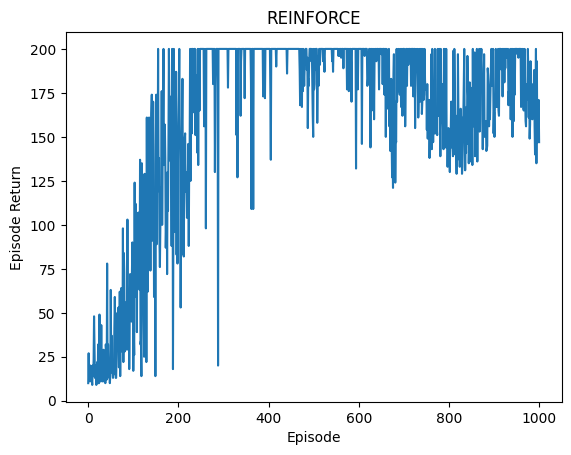

In [57]:
# JIT the choose_action and learn functions for more speed
REINFORCE_learn_jit = jax.jit(REINFORCE_learn)
REINFORCE_choose_action_jit = jax.jit(REINFORCE_choose_action)

# Initial learn state
REINFORCE_learn_state = REINFORCELearnState(REINFORCE_optim_state)

# Run training loop
print("Starting training. This may take up to 10 minutes to complete.")
episode_returns, evaluator_returns = run_training_loop(
                                        env_name,
                                        REINFORCE_params,
                                        REINFORCE_choose_action_jit,
                                        None, # action state not used
                                        REINFORCE_learn_jit,
                                        REINFORCE_learn_state,
                                        REINFORCE_memory,
                                        num_episodes=1001,
                                        learn_steps_per_episode=2,
                                        video_subdir="reinforce"
                                      )

# Plot the episode returns
plt.plot(episode_returns)
plt.xlabel("Episode")
plt.ylabel("Episode Return")
plt.title("REINFORCE")
plt.show()

In [62]:
#@title Визуализация {display-mode: "form"}
#@markdown Выберите номер эпизода, менее или равного 1000, и **run this cell**.

episode_number = 1000 #@param {type:"number"}

assert (episode_number % 100) == 0, "Episode number must be a multiple of 100 since we only record every 100th episode."
assert episode_number < 1001, "Episode number must be less than or equal to 1000"

eval_episode_number = int(episode_number / 100 * 8)
video_path = f"./video/reinforce/eval/rl-video-episode-{eval_episode_number}.mp4"

mp4 = open(video_path,'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML("""
<video width=400 controls>
      <source src="%s" type="video/mp4">
</video>
""" % data_url)

### Q-Learning

### Greedy action selection №10

In [63]:
def select_greedy_action(q_values):
    action = jnp.argmax(q_values)
    return action

In [64]:
# @title Проверка упр 10 (run me) {display-mode: "form"}

try:
  q_values = jnp.array([1,1,3,4])
  action = select_greedy_action(q_values)

  if action != 3:
    print("Incorrect answer, your greedy action selector looks wrong")
  else:
    print("Looks good.")
except Exception as e:
  print("An Error Occured: {}".format(e))

Looks good.


### Q-Network

In [65]:
def build_network(num_actions: int, layers=[20, 20]) -> hk.Transformed:
  """Factory for a simple MLP network for approximating Q-values."""

  def q_network(obs):
    network = hk.Sequential(
        [hk.Flatten(),
         hk.nets.MLP(layers + [num_actions])])
    return network(obs)

  return hk.without_apply_rng(hk.transform(q_network))

In [66]:
# Initialise Q-network
Q_NETWORK = build_network(num_actions=num_actions, layers=[20, 20]) # two actions

dummy_obs = jnp.zeros((1,*obs_shape), jnp.float32) # a dummy observation like the one in CartPole

random_key = jax.random.PRNGKey(42) # random key
Q_NETWORK_PARAMS = Q_NETWORK.init(random_key, dummy_obs) # Get initial params

print("Q-Learning params:", Q_NETWORK_PARAMS.keys())

Q-Learning params: dict_keys(['mlp/~/linear_0', 'mlp/~/linear_1', 'mlp/~/linear_2'])


### Функция квадратичной ошибки №11

In [67]:
def compute_squared_error(pred, target):
    squared_error = (pred - target) ** 2
    return squared_error

In [68]:
#@title Проверка упр 11 {display-mode: "form"}

try:
  result = compute_squared_error(1, 4)

  if result != 9:
    print("Your implementation looks wrong.")
  else:
    print("Looks good.")
except Exception as e:
  print("An Error Occured: {}".format(e))

Looks good.


### Цель Балламана №12

In [69]:
def compute_bellman_target(reward, done, next_q_values):
    bellman_target = reward + (1.0 - done) * jnp.max(next_q_values)
    return bellman_target

In [70]:
#@title Проверка упр 12 {display-mode: "form"}

try:
  # not done
  result1 = compute_bellman_target(1, 0.0, np.array([3,2], "float32"))

  # done
  result2 = compute_bellman_target(1, 1.0, np.array([3,2], "float32"))

  if result1 != 4 or result2 != 1:
    print("Your implementation looks wrong.")
  else:
    print("Looks good.")
except Exception as e:
  print("An Error Occured: {}".format(e))

Looks good.


### Функция потери Q-обучения №13

In [71]:
def q_learning_loss(q_values, action, reward, done, next_q_values):
    chosen_action_q_value = q_values[action]
    bellman_target = reward + (1.0 - done) * jnp.max(next_q_values)
    squared_error = (chosen_action_q_value - bellman_target) ** 2
    return squared_error

In [72]:
#@title Проверка упр 13 {display-mode: "form"}

try:
  result = q_learning_loss(np.array([3,2], "float32"), 1, 2, 0.0, np.array([3,2], "float32"))

  if result != 9.0:
    print("Your implementation looks wrong.")
  else:
    print("Looks good.")
except Exception as e:
  print("An Error Occured: {}".format(e))

Looks good.


### Target Q-Network

In [73]:
# Store online and target parameters
QLearnParams = collections.namedtuple("Params", ["online", "target"])

# Q-learn-state
QLearnState = collections.namedtuple("LearnerState", ["count", "optim_state"])

In [74]:
# Initialise Q-network optimizer
Q_LEARN_OPTIMIZER = optax.adam(3e-4) # learning rate

Q_LEARN_OPTIM_STATE = Q_LEARN_OPTIMIZER.init(Q_NETWORK_PARAMS) # initial optim state

# Create Learn State
Q_LEARNING_LEARN_STATE = QLearnState(0, Q_LEARN_OPTIM_STATE) # count set to zero initially

# Add initial Q-network weights to QLearnParams object
Q_LEARNING_PARAMS = QLearnParams(online=Q_NETWORK_PARAMS, target=Q_NETWORK_PARAMS) # target equal to online

In [75]:
def update_target_params(learn_state, online_weights, target_weights):
  """A function to update target params every 100 training steps"""

  target = jax.lax.cond(
      jax.numpy.mod(learn_state.count, 100) == 0,
      lambda x, y: x,
      lambda x, y: y,
      online_weights,
      target_weights
  )

  params = QLearnParams(online_weights, target)

  return params

### Q-learning loss

In [76]:
def batched_q_learning_loss(online_params, target_params, obs, actions, rewards, next_obs, dones):
    q_values = Q_NETWORK.apply(online_params, obs) # use the online parameters
    next_q_values = Q_NETWORK.apply(target_params, next_obs) # use the target parameters
    squared_error = jax.vmap(q_learning_loss)(q_values, actions, rewards, dones, next_q_values) # vmap q_learning_loss
    mean_squared_error = jnp.mean(squared_error) # mean squared error over batch
    return mean_squared_error

In [77]:
def q_learn(rng, params, learner_state, memory):
  # Compute gradients
  grad_loss = jax.grad(batched_q_learning_loss)(params.online, params.target, memory.obs,
                                          memory.action, memory.reward,
                                          memory.next_obs, memory.done,
                                          ) # jax.grad

  # Get updates
  updates, opt_state = Q_LEARN_OPTIMIZER.update(grad_loss, learner_state.optim_state)

  # Apply them
  new_weights = optax.apply_updates(params.online, updates)

  # Maybe update target network
  params = update_target_params(learner_state, new_weights, params.target)

  # Increment learner step counter
  learner_state = QLearnState(learner_state.count + 1, opt_state)

  return params, learner_state

### Replay Buffer

In [78]:
class TransitionMemory(object):
  """A simple Python replay buffer."""

  def __init__(self, max_size=10_000, batch_size=256):
    self.batch_size = batch_size
    self.buffer = collections.deque(maxlen=max_size)

  def push(self, transition):

    # add transition to the replay buffer
    self.buffer.append(
        (transition.obs, transition.action, transition.reward,
          transition.next_obs, transition.done)
    )


  def is_ready(self):
    return self.batch_size <= len(self.buffer)

  def sample(self):
    # Randomly sample a batch of transitions from the buffer
    random_replay_sample = random.sample(self.buffer, self.batch_size)

    # Batch the transitions together
    obs_batch, action_batch, reward_batch, next_obs_batch, done_batch = zip(*random_replay_sample)

    return Transition(
        np.stack(obs_batch).astype("float32"),
        np.asarray(action_batch).astype("int32"),
        np.asarray(reward_batch).astype("float32"),
        np.stack(next_obs_batch).astype("float32"),
        np.asarray(done_batch).astype("float32")
    )

# Instantiate the memory
Q_LEARNING_MEMORY = TransitionMemory(max_size=50_000, batch_size=256)

### Случайное исследование №14

In [79]:
def select_random_action(key, num_actions):
    action = jax.random.randint(key, shape=(), minval=0, maxval=num_actions)
    return action

In [80]:
#@title Проверка упр 14 {display-mode: "form"}

try:
  random_key1 = random_key = jax.random.PRNGKey(6) # random key
  random_key2 = random_key = jax.random.PRNGKey(1000) # random key
  result1 = select_random_action(random_key1, 2)
  result2 = select_random_action(random_key2, 2)

  if result1 != 1 or result2 != 0:
    print("Your implementation looks wrong.")
  else:
    print("Looks good.")
except:
  print("Your implementation looks wrong.")

Looks good.


### Эпсилон жадный выбор действия №15

In [81]:
EPSILON_DECAY_TIMESTEPS = 3000 # decay epsilon over 3000 timesteps
EPSILON_MIN = 0.1 # 10% exploration

In [82]:
def get_epsilon(num_timesteps):
    epsilon = 1.0 - (num_timesteps / EPSILON_DECAY_TIMESTEPS)
    epsilon = jax.lax.select(
        epsilon < EPSILON_MIN,
        EPSILON_MIN,
        epsilon
    )
    return epsilon

In [83]:
#@title Проверка упр 15 {display-mode: "form"}
def check_get_epsilon(get_epsilon):
  try:
    result1 = get_epsilon(10)
    result2 = get_epsilon(5_010)

    if result1 != 0.99666667 or result2 != 0.1:
      print("Your function looks wrong.")
    else:
      print("Your function looks correct.")
  except:
    print("Your function looks wrong.")

check_get_epsilon(get_epsilon)

Your function looks correct.


### Объединение функций №16

In [84]:
def select_epsilon_greedy_action(key, q_values, num_timesteps):
    num_actions = len(q_values)

    epsilon = get_epsilon(num_timesteps)  # Compute epsilon value
    should_explore = jax.random.uniform(key) < epsilon  # Determine if exploration should happen

    action = jax.lax.select(
        should_explore,
        jax.random.randint(key, shape=(), minval=0, maxval=num_actions),  # Explore: random action
        jnp.argmax(q_values)  # Exploit: greedy action
    )

    return action

In [86]:
#@title Проверка упражнения 16 {display-mode: "form"}

try:
  rng = hk.PRNGSequence(jax.random.PRNGKey(42))
  dummy_q_values = jnp.array([0,1], jnp.float32)
  num_timesteps = 5010 # very greedy
  actions1 = []
  for i in range(10):
      actions1.append(int(select_epsilon_greedy_action(next(rng), dummy_q_values, num_timesteps)))

  num_timesteps = 0 # completly random
  actions2 = []
  for i in range(10):
      actions2.append(int(select_epsilon_greedy_action(next(rng), dummy_q_values, num_timesteps)))

  if actions1 != [1, 1, 0, 1, 1, 0, 1, 1, 1, 1] or actions2 != [0, 0, 0, 1, 1, 1, 1, 0, 0, 0]:
    print("Looks like something might be incorrect!")
  else:
    print("Looks correct!")
except:
  print("Looks like something might be incorrect!")

Looks correct!


### Действие выбора Q-learning

In [87]:
# Actor state stores the current number of timesteps
QActorState = collections.namedtuple("ActorState", ["count"])

def q_learning_select_action(key, params, actor_state, obs, evaluation=False):
    obs = jnp.expand_dims(obs, axis=0) # add dummy batch dim
    q_values = Q_NETWORK.apply(params.online, obs)[0] # remove batch dim

    action = select_epsilon_greedy_action(key, q_values, actor_state.count)
    greedy_action = select_greedy_action(q_values)

    action = jax.lax.select(
        evaluation,
        greedy_action,
        action
    )

    next_actor_state = QActorState(actor_state.count + 1) # increment timestep counter

    return action, next_actor_state

Q_LEARNING_ACTOR_STATE = QActorState(0) # counter set to zero

### Обучение

Starting training. This may take up to 8 minutes to complete.


/usr/local/lib/python3.10/dist-packages/gym/envs/registration.py:593: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(
/usr/local/lib/python3.10/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.10/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/lib/python3.10/subprocess.py:1796: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.p

Episode: 0	Episode Return: 12.0	Average Episode Return: 12.0	Evaluator Episode Return: 9.375


/usr/lib/python3.10/subprocess.py:1796: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _posixsubprocess.fork_exec(
/usr/lib/python3.10/subprocess.py:1796: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _posixsubprocess.fork_exec(


Episode: 100	Episode Return: 14.0	Average Episode Return: 13.75	Evaluator Episode Return: 9.5


...

Episode: 800	Episode Return: 200.0	Average Episode Return: 184.95	Evaluator Episode Return: 186.625


/usr/lib/python3.10/subprocess.py:1796: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _posixsubprocess.fork_exec(
/usr/lib/python3.10/subprocess.py:1796: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _posixsubprocess.fork_exec(


Episode: 900	Episode Return: 200.0	Average Episode Return: 200.0	Evaluator Episode Return: 200.0


/usr/lib/python3.10/subprocess.py:1796: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _posixsubprocess.fork_exec(
/usr/lib/python3.10/subprocess.py:1796: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _posixsubprocess.fork_exec(


Episode: 1000	Episode Return: 15.0	Average Episode Return: 24.85	Evaluator Episode Return: 15.0


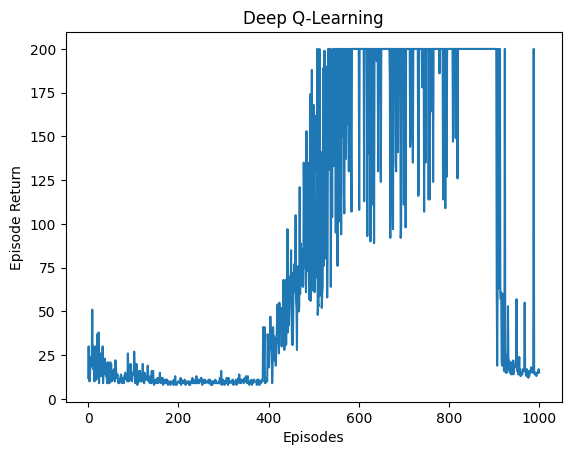

In [88]:
# Jit functions
q_learning_select_action_jit = jax.jit(q_learning_select_action)
q_learn_jit = jax.jit(q_learn)

# Run environment loop
print("Starting training. This may take up to 8 minutes to complete.")
episode_returns, evaluator_returns = run_training_loop(
                                        env_name,
                                        Q_LEARNING_PARAMS,
                                        q_learning_select_action_jit,
                                        Q_LEARNING_ACTOR_STATE,
                                        q_learn_jit,
                                        Q_LEARNING_LEARN_STATE,
                                        Q_LEARNING_MEMORY,
                                        num_episodes=1001,
                                        train_every_timestep=True, # do learning after every timestep
                                        video_subdir="q_learning"
                                    )

plt.plot(episode_returns)
plt.xlabel("Episodes")
plt.ylabel("Episode Return")
plt.title("Deep Q-Learning")
plt.show()

In [89]:
#@title Визуализация политики
#@markdown Выберите номер эпизода, кратный 100 и меньший или равный 1000, и **запустите эту ячейку**.
episode_number = 600 #@param {type:"number"}

assert (episode_number % 100) == 0, "Episode number must be a multiple of 100 since we only record every 100th episode."
assert episode_number < 1001, "Episode number must be less than or equal to 1000"


eval_episode_number = int(episode_number / 100 * 8)
video_path = f"./video/q_learning/eval/rl-video-episode-{eval_episode_number}.mp4"

mp4 = open(video_path,'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML("""
<video width=400 controls>
      <source src="%s" type="video/mp4">
</video>
""" % data_url)